# How does literacy vary across the districts and divisons of Bangladesh?

##  Setup & Data Loading

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("housing_census_cleaned.csv")

In [3]:

df.head()

,division,district,division_geocode,district_geocode,household_total,population_total,household_excluding_slum_floating,population_excluding_slum_floating,household_slum,population_slum,...,number_of_person_avg_hh_size__of_hh_with_3person,number_of_person_avg_hh_size__of_hh_with_4person,number_of_person_avg_hh_size__of_hh_with_5person,number_of_person_avg_hh_size__of_hh_with_6person,number_of_person_avg_hh_size__of_hh_with_7person,number_of_person_avg_hh_size__of_hh_with_8person,number_of_person_avg_hh_size__of_hh_with_9person,number_of_person_avg_hh_size__of_hh_with_10person,number_of_person_avg_hh_size__of_hh_with_10person_,number_of_person_avg_hh_size_average_household_size
0,Barishal,Barguna,10,4,255390,1010531,254895,1008695,451,1789,...,57097,68828,43330,20901,8395,3499,1583,772,767,3.92
1,Khulna,Bagerhat,40,1,408840,1613076,406058,1603126,2605,9763,...,96057,109638,68442,32081,12933,5722,2560,1324,1236,3.89
2,Barishal,Barishal,10,6,629626,2570446,620735,2537292,8160,31338,...,135271,165285,110132,54039,23613,10535,5289,2819,2981,4.02
3,Barishal,Bhola,10,9,449057,1932518,448944,1932138,74,339,...,89014,118802,92260,46329,20396,9347,4588,2375,2574,4.27
4,Barishal,Jhalokati,10,42,162401,661160,162212,660520,143,588,...,34540,41357,27852,14052,6339,3084,1529,815,904,4.02


### District-Level Literacy Analysis



From the cleaned dataset, the appropriate literacy variables were extracted for the population aged 7 years and above. In this analysis, I have not included the 5+ age group because children aged 5–6 are generally at the pre-primary level. At this stage, they are learning basic alphabet recognition and phonics, but most have not yet acquired the ability to read and write short, simple statements with understanding. Including 5–6-year-olds could lower the measured literacy rate , as many children in this age group are simply too young to have received sufficient formal instruction in reading and writing. 


On the other hand, children aged 7 and above are more likely to have received formal instruction in reading and writing, making this age group a more appropriate basis for assessing literacy. Therefore, I have started the analysis with this age group.


The male, female, and overall literacy rates are converted to numeric values. Any non-numeric values are treated as missing values.

A separate district-level DataFrame is then created containing the following variables:


* Division
* District
* Male literacy rate (7+)
* Female literacy rate (7+)
* Overall literacy rate (7+)
* Gender literacy gap
* Gender Parity Index (GPI)


Literacy Rate= (Number of literate people / Total population in the age group ) * 100

The gender literacy gap is calculated as:

Gender Gap = Male Literacy Rate − Female Literacy Rate

A positive value indicates that the male literacy rate is higher than the female literacy rate, while a negative value indicates the opposite.

The Gender Parity Index is calculated as:

GPI = Female Literacy Rate / Male Literacy Rate

A GPI value of 1 indicates equal literacy rates between males and females. A value below 1 indicates that the female literacy rate is lower than the male literacy rate, while a value above 1 indicates that the female literacy rate is higher.



In [4]:
pop_m = "population_by_sex_dist_loca_population_male_"
pop_f = "population_by_sex_dist_loca_population_female_"
pop_tot = "population_total"

lit_m_7 = pd.to_numeric( df["literacy_rate_7year_male"], errors="coerce" )

lit_f_7 = pd.to_numeric( df["literacy_rate_7year_female"], errors="coerce")

lit_tot_7 = pd.to_numeric( df["literacy_rate_7year_overall"], errors="coerce")

district_df = pd.DataFrame({ "division": df["division"], "district": df["district"], "Male_Lit_7+": lit_m_7, "Female_Lit_7+": lit_f_7,
                             "Overall_Lit_7+": lit_tot_7, "Gender_Gap": (lit_m_7 - lit_f_7).round(2), "GPI": (lit_f_7 / lit_m_7).round(3)})

district_df = district_df.sort_values( "Overall_Lit_7+", ascending=False).reset_index(drop=True)

pd.set_option("display.max_rows", 70)

print(district_df.to_string(index=False))

  division        district  Male_Lit_7+  Female_Lit_7+  Overall_Lit_7+  Gender_Gap   GPI
  Barishal        Pirojpur        86.01          85.09           85.53        0.92 0.989
     Dhaka           Dhaka        86.45          83.06           84.88        3.39 0.961
  Barishal       Jhalokati        84.15          82.35           83.21        1.80 0.979
    Khulna        Bagerhat        82.49          80.37           81.42        2.12 0.974
     Dhaka         Gazipur        83.64          79.01           81.42        4.63 0.945
Chattogram      Chattogram        82.88          79.26           81.06        3.62 0.956
Chattogram            Feni        82.58          79.21           80.79        3.37 0.959
    Khulna          Khulna        83.62          77.70           80.66        5.92 0.929
  Barishal         Barguna        82.28          79.10           80.65        3.18 0.961
  Barishal        Barishal        80.81          78.94           79.85        1.87 0.977
     Dhaka       Gopa

##   Male vs female literacy (7+) barchart : Top 5 and bottom 5 districts

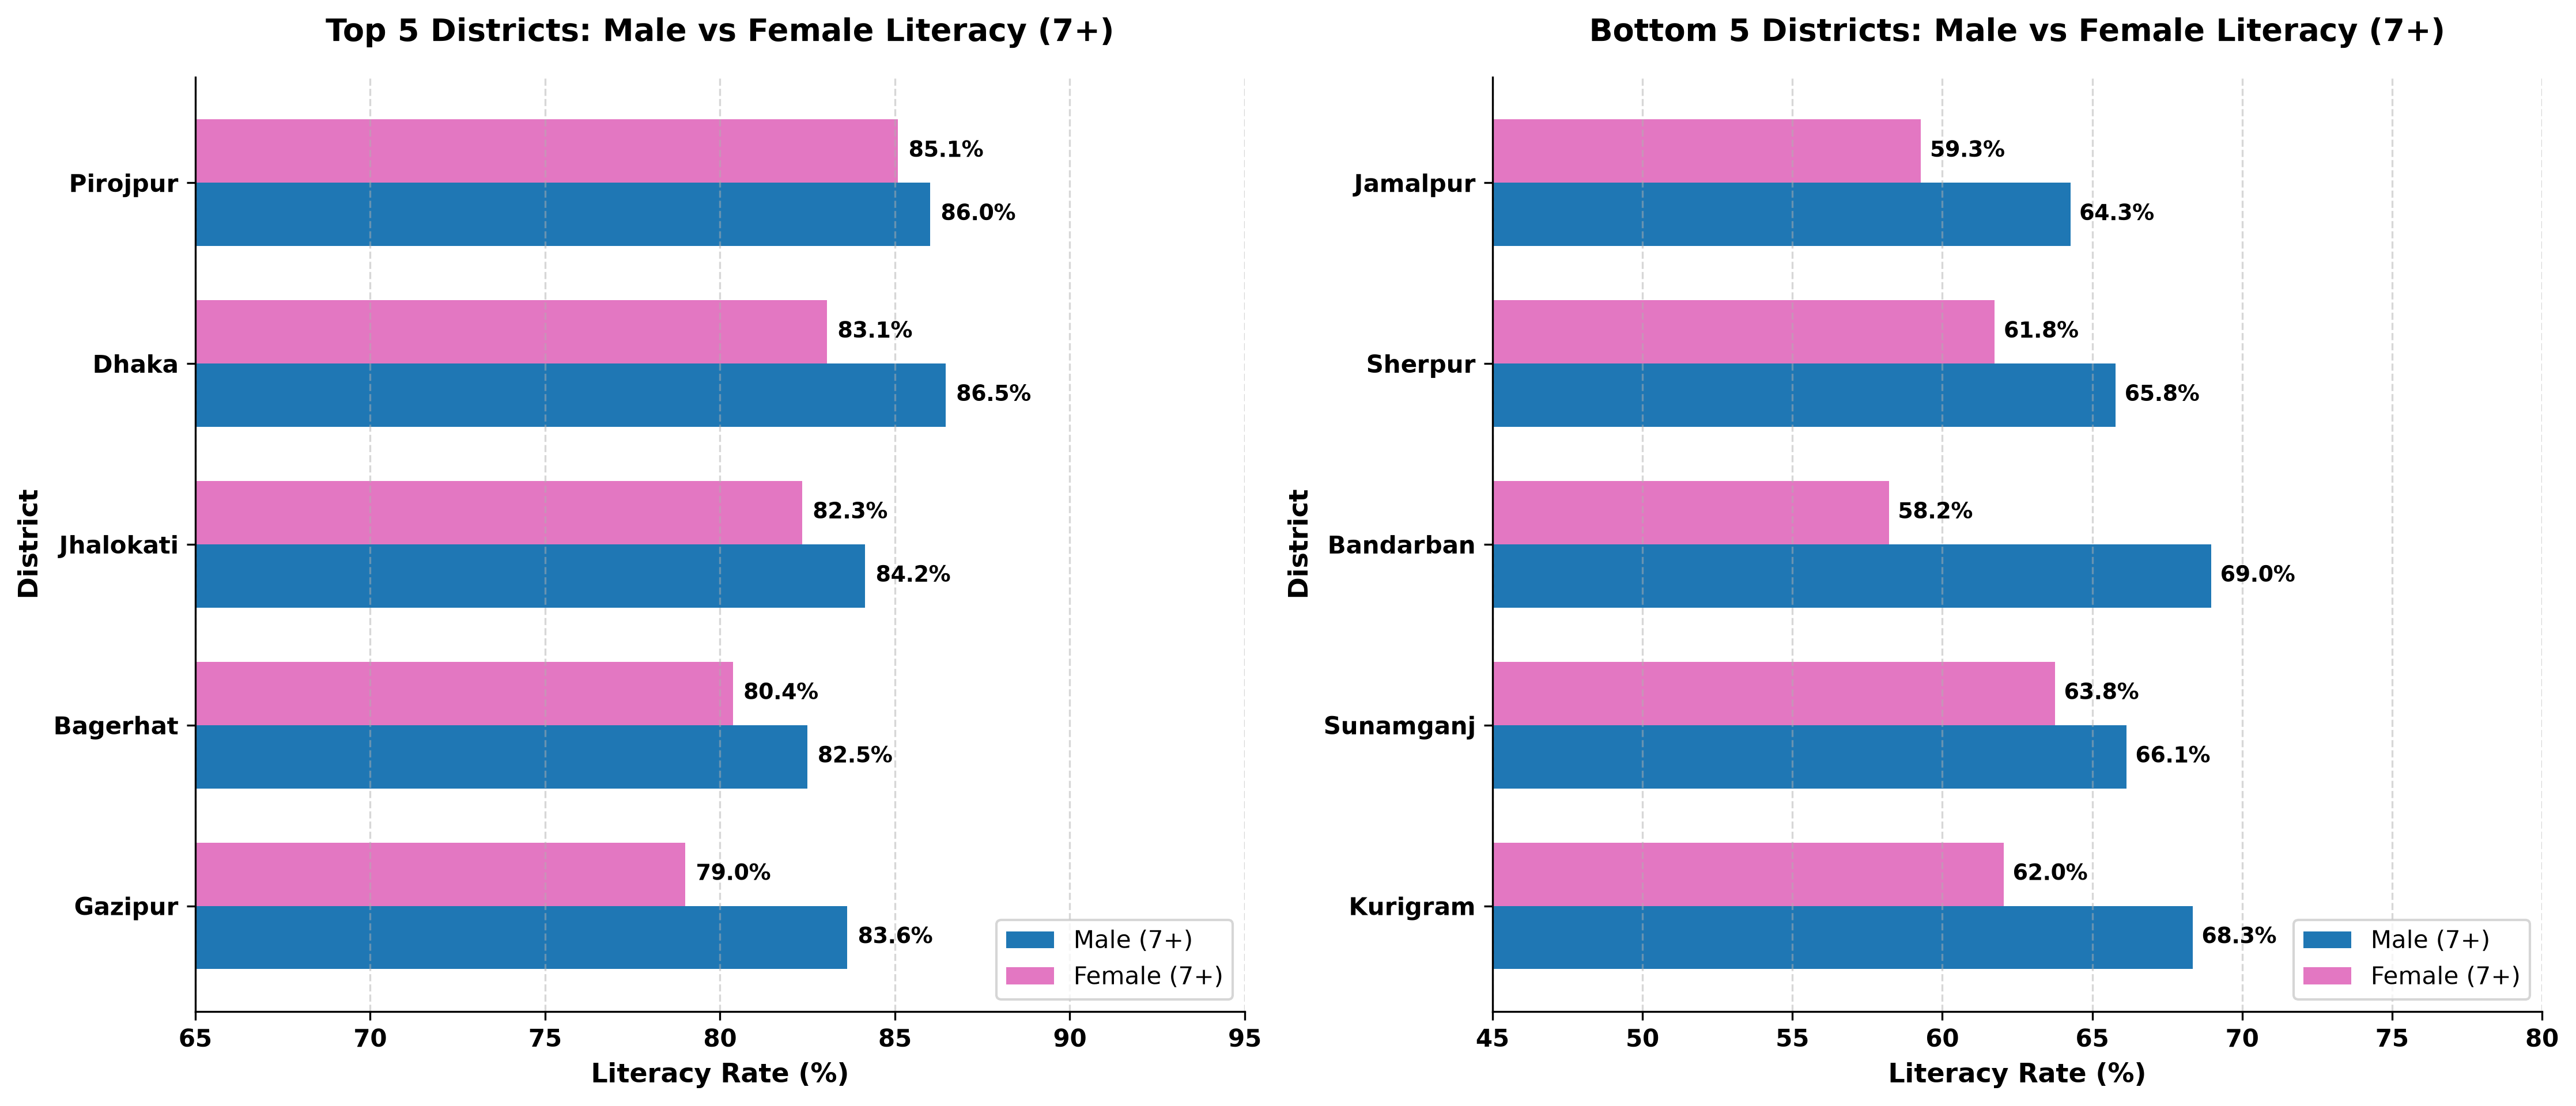

In [15]:
lit_m = "literacy_rate_7year_male"
lit_f = "literacy_rate_7year_female"
lit_tot = "literacy_rate_7year_overall"


data_df = pd.DataFrame(
    {
        "District": df["district"],
        "Lit_M_7": pd.to_numeric(
            df[lit_m],
            errors="coerce"
        ),
        "Lit_F_7": pd.to_numeric(
            df[lit_f],
            errors="coerce"
        ),
        "Lit_Tot_7": pd.to_numeric(
            df[lit_tot],
            errors="coerce"
        ),
    }
)


data_df["Gender_Gap"] = (
    data_df["Lit_M_7"] - data_df["Lit_F_7"]
)

data_df["GPI"] = (
    data_df["Lit_F_7"] / data_df["Lit_M_7"]
)


top5 = (
    data_df
    .sort_values("Lit_Tot_7", ascending=False)
    .head(5)
    .iloc[::-1]
)

bottom5 = (
    data_df
    .sort_values("Lit_Tot_7", ascending=True)
    .head(5)
    .iloc[::-1]
)



fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6.5),
    dpi=300
)

bar_height = 0.35


y_top = np.arange(len(top5))

bars_m_top = axes[0].barh(
    y_top - bar_height / 2,
    top5["Lit_M_7"],
    bar_height,
    label="Male (7+)",
    color="#1f77b4"
)

bars_f_top = axes[0].barh(
    y_top + bar_height / 2,
    top5["Lit_F_7"],
    bar_height,
    label="Female (7+)",
    color="#e377c2"
)

axes[0].set_yticks(y_top)
axes[0].set_yticklabels(top5["District"])

axes[0].set_title(
    "Top 5 Districts: Male vs Female Literacy (7+)",
    fontsize=13,
    fontweight="bold",
    pad=15
)

axes[0].set_xlabel(
    "Literacy Rate (%)",
    fontsize=11,
    fontweight="bold"
)

axes[0].set_ylabel(
    "District",
    fontsize=11,
    fontweight="bold"
)

axes[0].set_xlim(65, 95)

axes[0].legend(
    loc="lower right",
    frameon=True
)




for bar in bars_m_top:

    width = bar.get_width()

    axes[0].text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=9,
        fontweight="bold"
    )


for bar in bars_f_top:

    width = bar.get_width()

    axes[0].text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=9,
        fontweight="bold"
    )



y_bottom = np.arange(len(bottom5))

bars_m_bottom = axes[1].barh(
    y_bottom - bar_height / 2,
    bottom5["Lit_M_7"],
    bar_height,
    label="Male (7+)",
    color="#1f77b4"
)

bars_f_bottom = axes[1].barh(
    y_bottom + bar_height / 2,
    bottom5["Lit_F_7"],
    bar_height,
    label="Female (7+)",
    color="#e377c2"
)

axes[1].set_yticks(y_bottom)
axes[1].set_yticklabels(bottom5["District"])

axes[1].set_title(
    "Bottom 5 Districts: Male vs Female Literacy (7+)",
    fontsize=13,
    fontweight="bold",
    pad=15
)

axes[1].set_xlabel(
    "Literacy Rate (%)",
    fontsize=11,
    fontweight="bold"
)

axes[1].set_ylabel(
    "District",
    fontsize=11,
    fontweight="bold"
)

axes[1].set_xlim(45, 80)

axes[1].legend(
    loc="lower right",
    frameon=True
)




for bar in bars_m_bottom:

    width = bar.get_width()

    axes[1].text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=9,
        fontweight="bold"
    )


for bar in bars_f_bottom:

    width = bar.get_width()

    axes[1].text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=9,
        fontweight="bold"
    )




for ax in axes:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.5
    )

    ax.tick_params(
        axis="both",
        labelsize=10
    )

    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")


plt.tight_layout()

plt.savefig(
    "district_male_vs_female_literacy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Literacy rate across Divisions

In [6]:
pop_m = "population_by_sex_dist_loca_population_male_"
pop_f = "population_by_sex_dist_loca_population_female_"
pop_tot = "population_total"


data_df = pd.DataFrame(
    {
        "Division": df["division"],
        "Pop_M": pd.to_numeric(
            df[pop_m],
            errors="coerce"
        ),
        "Pop_F": pd.to_numeric(
            df[pop_f],
            errors="coerce"
        ),
        "Pop_Tot": pd.to_numeric(
            df[pop_tot],
            errors="coerce"
        ),
        "Lit_M_7": pd.to_numeric(
            df["literacy_rate_7year_male"],
            errors="coerce"
        ),
        "Lit_F_7": pd.to_numeric(
            df["literacy_rate_7year_female"],
            errors="coerce"
        ),
        "Lit_Tot_7": pd.to_numeric(
            df["literacy_rate_7year_overall"],
            errors="coerce"
        ),
    }
)

data_df["District_Gender_Gap"] = (
    data_df["Lit_M_7"] - data_df["Lit_F_7"]
)

data_df["District_GPI"] = (
    data_df["Lit_F_7"] / data_df["Lit_M_7"]
)

div_results = []

for div, group in data_df.groupby("Division"):

    w_male_lit = (
        (group["Lit_M_7"] * group["Pop_M"]).sum()
        / group["Pop_M"].sum()
    )

    w_fem_lit = (
        (group["Lit_F_7"] * group["Pop_F"]).sum()
        / group["Pop_F"].sum()
    )

    w_tot_lit = (
        (group["Lit_Tot_7"] * group["Pop_Tot"]).sum()
        / group["Pop_Tot"].sum()
    )

    div_results.append(
        {
            "Division": div,
            "Weighted_Male_Lit_7+": round(w_male_lit, 2),
            "Weighted_Female_Lit_7+": round(w_fem_lit, 2),
            "Weighted_Overall_Lit_7+": round(w_tot_lit, 2),
            "Gender_Gap": round(
                w_male_lit - w_fem_lit,
                2
            ),
            "GPI": round(
                w_fem_lit / w_male_lit,
                3
            ),
        }
    )

div_summary = pd.DataFrame(div_results)


div_summary = div_summary.sort_values(
    "Weighted_Overall_Lit_7+",
    ascending=False
)


print(div_summary.to_string(index=False)
)

  Division  Weighted_Male_Lit_7+  Weighted_Female_Lit_7+  Weighted_Overall_Lit_7+  Gender_Gap   GPI
     Dhaka                 80.13                   76.12                    78.16        4.00 0.950
  Barishal                 78.59                   76.80                    77.67        1.79 0.977
Chattogram                 77.84                   75.55                    76.13        2.29 0.971
    Khulna                 77.27                   73.05                    75.13        4.22 0.945
  Rajshahi                 73.99                   70.05                    72.14        3.94 0.947
    Sylhet                 73.63                   70.49                    72.01        3.14 0.957
   Rangpur                 73.99                   67.79                    70.85        6.20 0.916
Mymensingh                 68.95                   65.64                    67.25        3.31 0.952


## Division level overall population weighthed (7+)

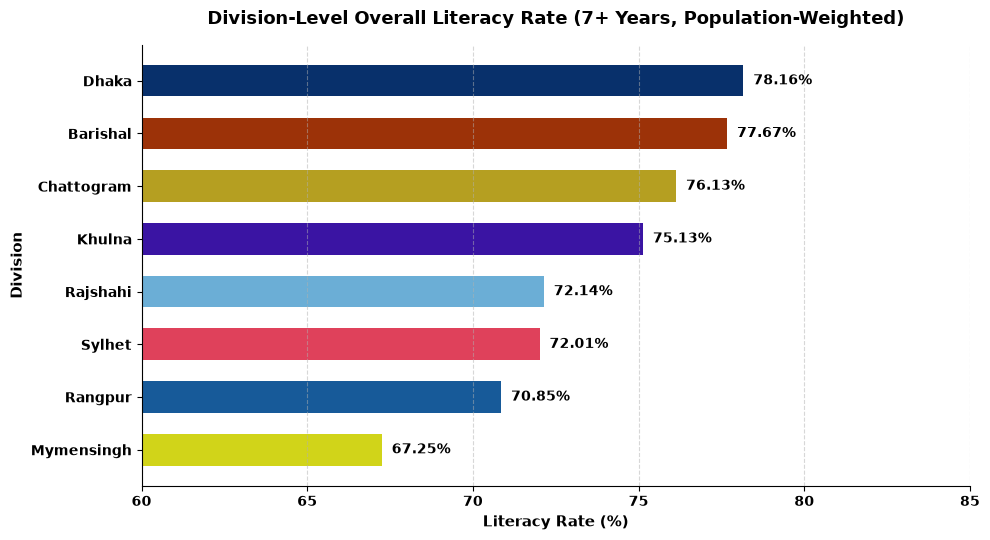

In [7]:

fig1, ax1 = plt.subplots(figsize=(10, 5.5))

div_plot = div_summary.iloc[::-1]

colors = [
    "#08306b", "#9c3208", "#b59f21", "#3a14a3",
    "#6baed6", "#df415b", "#175a99", "#d1d419"
][::-1]

bars = ax1.barh(
    div_plot["Division"],
    div_plot["Weighted_Overall_Lit_7+"],
    color=colors,
    height=0.6
)

ax1.set_title(
    "Division-Level Overall Literacy Rate (7+ Years, Population-Weighted)",
    fontsize=13, fontweight="bold", pad=15
)

ax1.set_xlabel("Literacy Rate (%)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Division", fontsize=11, fontweight="bold")
ax1.set_xlim(60, 85)

for tick in ax1.get_yticklabels():
    tick.set_fontweight("bold")

for tick in ax1.get_xticklabels():
    tick.set_fontweight("bold")

for bar in bars:
    w = bar.get_width()
    ax1.text(
        w + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.2f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig("Division level overall population weighthed (7+)",dpi=300)
plt.show()

## Division level Male vs Female literacy comparision(7+)

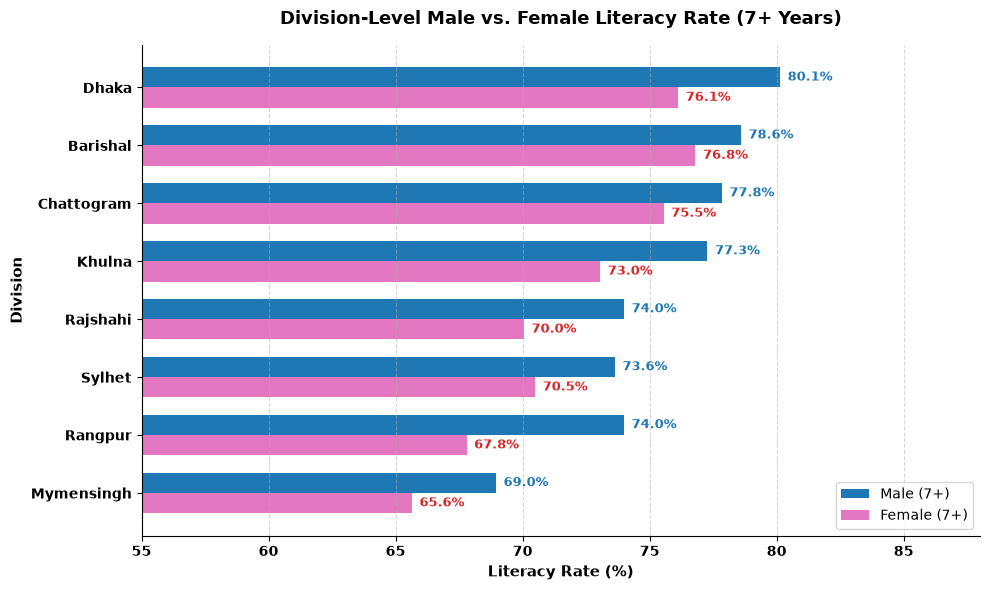

In [8]:


fig2, ax2 = plt.subplots(figsize=(10, 6))

divisions = div_summary["Division"]
male_lit = div_summary["Weighted_Male_Lit_7+"]
female_lit = div_summary["Weighted_Female_Lit_7+"]

y = np.arange(len(divisions))
height = 0.35

rects1 = ax2.barh(
    y - height / 2,
    male_lit,
    height,
    label="Male (7+)",
    color="#1f77b4"
)

rects2 = ax2.barh(
    y + height / 2,
    female_lit,
    height,
    label="Female (7+)",
    color="#e377c2"
)

ax2.set_title(
    "Division-Level Male vs. Female Literacy Rate (7+ Years)",
    fontsize=13, fontweight="bold", pad=15
)

ax2.set_xlabel("Literacy Rate (%)", fontsize=11, fontweight="bold")
ax2.set_ylabel("Division", fontsize=11, fontweight="bold")

ax2.set_yticks(y)
ax2.set_yticklabels(divisions)
ax2.set_xlim(55, 88)
ax2.invert_yaxis()

ax2.legend(
    loc="lower right",
    frameon=True
)

for tick in ax2.get_yticklabels():
    tick.set_fontweight("bold")

for tick in ax2.get_xticklabels():
    tick.set_fontweight("bold")

for bar in rects1:
    w = bar.get_width()
    ax2.text(
        w + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.1f}%",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#1f77b4"
    )

for bar in rects2:
    w = bar.get_width()
    ax2.text(
        w + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.1f}%",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#d62728"
    )

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig("Division level Male vs Female literacy comparision(7+).png", dpi=300)
plt.show()

## Urban and Rural Literacy Rate Comparison Across Districts (7+ years)

=== Urban vs Rural Literacy Rate (7+ Years) for All 64 Districts ===
       District  Lit_Urban_7  Lit_Rural_7  Urban_Rural_Gap  Lit_Tot_7
       Pirojpur        88.33        84.83             3.50      85.53
          Dhaka        86.08        81.02             5.06      84.88
      Jhalokati        86.38        81.98             4.40      83.21
       Bagerhat        82.23        81.17             1.06      81.42
        Gazipur        83.32        77.95             5.37      81.42
     Chattogram        83.48        78.22             5.26      81.06
           Feni        84.02        79.41             4.61      80.79
         Khulna        85.53        77.28             8.25      80.66
        Barguna        85.21        79.30             5.91      80.65
       Barishal        85.43        77.40             8.03      79.85
      Gopalganj        85.36        78.44             6.92      79.84
    Narayanganj        81.41        77.74             3.67      79.24
       Chandpur      

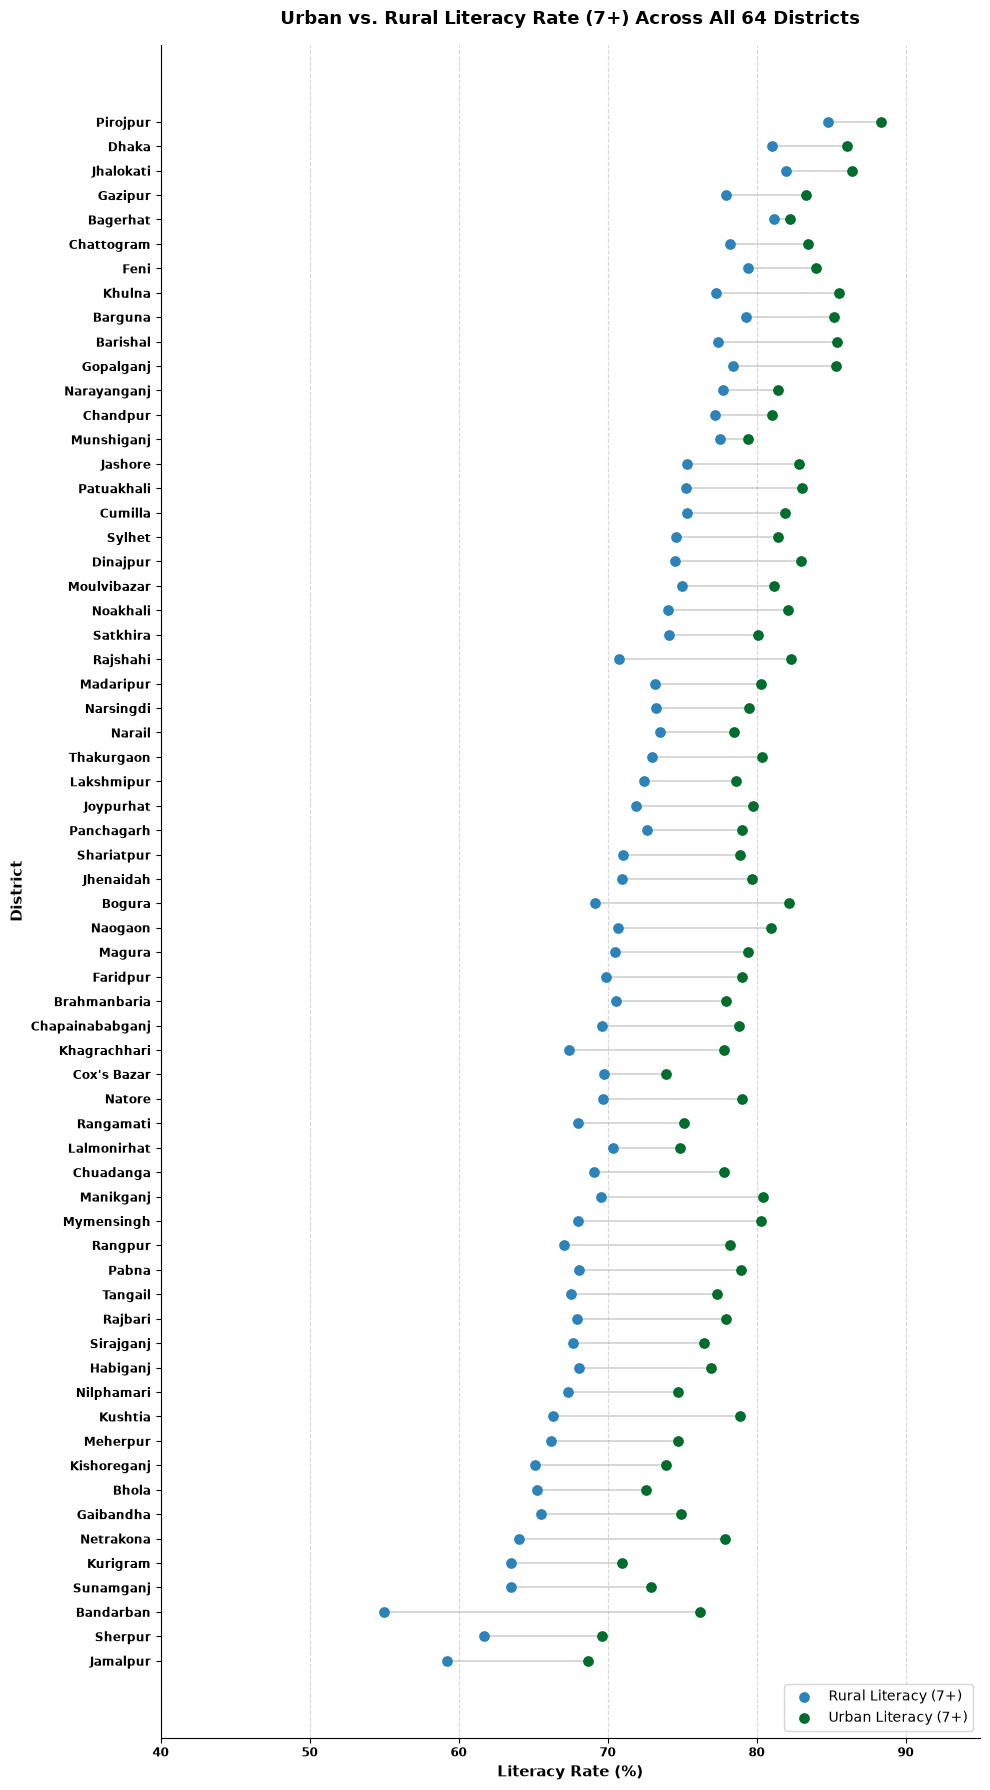

In [16]:
plot_df = pd.DataFrame(
    {
        "District": df["district"],
        "Lit_Rural_7": pd.to_numeric(
            df["rural_literacy_rate_7year_overall"],
            errors="coerce"
        ),
        "Lit_Urban_7": pd.to_numeric(
            df["urban_literacy_rate_7year_overall"],
            errors="coerce"
        ),
        "Lit_Tot_7": pd.to_numeric(
            df["literacy_rate_7year_overall"],
            errors="coerce"
        ),
    }
)



district_df = (
    plot_df
    .drop_duplicates(subset=["District"])
    .copy()
)

district_df["Urban_Rural_Gap"] = (
    district_df["Lit_Urban_7"]
    - district_df["Lit_Rural_7"]
)


district_df = (
    district_df
    .sort_values("Lit_Tot_7", ascending=True)
    .reset_index(drop=True)
)


print(
    "=== Urban vs Rural Literacy Rate (7+ Years) "
    "for All 64 Districts ==="
)

district_list = (
    district_df[
        [
            "District",
            "Lit_Urban_7",
            "Lit_Rural_7",
            "Urban_Rural_Gap",
            "Lit_Tot_7"
        ]
    ]
    .sort_values("Lit_Tot_7", ascending=False)
)

print(
    district_list.to_string(index=False)
)


fig, ax = plt.subplots(figsize=(10, 18))


ax.hlines(
    y=district_df["District"],
    xmin=district_df["Lit_Rural_7"],
    xmax=district_df["Lit_Urban_7"],
    color="#bdbdbd",
    alpha=0.7,
    linewidth=1.2,
    zorder=1
)



ax.scatter(
    district_df["Lit_Rural_7"],
    district_df["District"],
    color="#2b83ba",
    label="Rural Literacy (7+)",
    s=45,
    zorder=3
)



ax.scatter(
    district_df["Lit_Urban_7"],
    district_df["District"],
    color="#006d2c",
    label="Urban Literacy (7+)",
    s=45,
    zorder=3
)



ax.set_title(
    "Urban vs. Rural Literacy Rate (7+) "
    "Across All 64 Districts",
    fontsize=13,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Literacy Rate (%)",
    fontsize=11,
    fontweight="bold"
)

ax.set_ylabel(
    "District",
    fontsize=11,
    fontweight="bold"
)

ax.set_xlim(40, 95)

ax.legend(
    loc="lower right",
    frameon=True,
    fontsize=10
)



ax.tick_params(
    axis="both",
    labelsize=8.5
)

for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")

for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.savefig( "all_64_districts_urban_rural_scatter.png",dpi=300)

plt.show()

## Overall Literacy Rate Across Districts

In [10]:


district_df = df.drop_duplicates( subset=["district"]).copy()

district_df["Literacy_7Plus_Overall"] = pd.to_numeric( district_df["literacy_rate_7year_overall"], errors="coerce")


district_df = district_df[ [ "district", "Literacy_7Plus_Overall" ]].copy()


district_df = district_df.sort_values( "Literacy_7Plus_Overall", ascending=False).reset_index(drop=True)


pd.set_option("display.max_rows", 70)

print(district_df.to_string(index=False))

       district  Literacy_7Plus_Overall
       Pirojpur                   85.53
          Dhaka                   84.88
      Jhalokati                   83.21
       Bagerhat                   81.42
        Gazipur                   81.42
     Chattogram                   81.06
           Feni                   80.79
         Khulna                   80.66
        Barguna                   80.65
       Barishal                   79.85
      Gopalganj                   79.84
    Narayanganj                   79.24
       Chandpur                   78.23
     Munshiganj                   77.90
        Jashore                   77.07
     Patuakhali                   76.70
        Cumilla                   76.68
         Sylhet                   76.43
       Dinajpur                   76.14
    Moulvibazar                   75.85
       Noakhali                   75.52
       Satkhira                   75.32
       Rajshahi                   75.17
      Madaripur                   74.93


### Among all 64 districts, Pirojpur has the highest literacy rate, at 85.33. In contrast, Jamalpur has the lowest literacy rate, at only 61.70%.

## Distribution of 64 Districts by Literacy rate (7+ years)

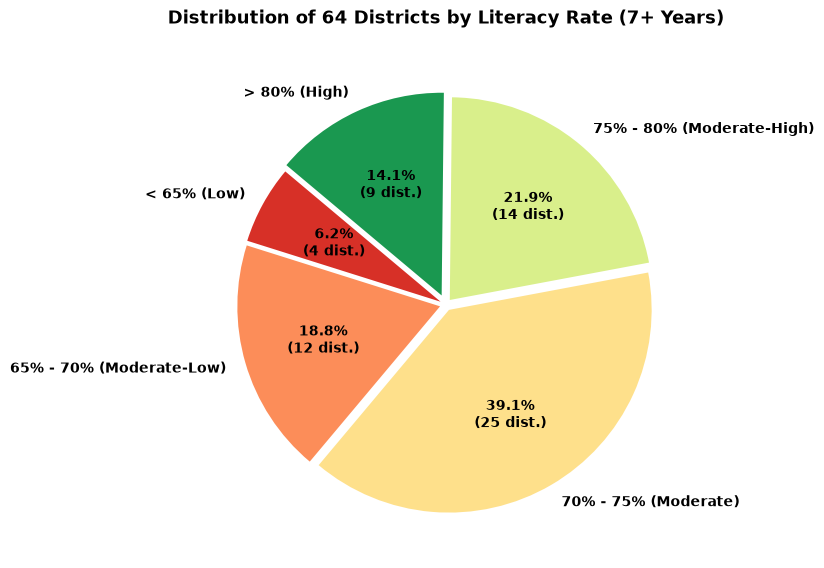

In [11]:
df = pd.read_csv("housing_census_cleaned.csv").copy()

district_df = df.drop_duplicates( subset=["district"]).copy()

district_df["Literacy_7Plus_Overall"] = pd.to_numeric( district_df["literacy_rate_7year_overall"], errors="coerce")



district_summary = ( district_df[[ "division", "district","Literacy_7Plus_Overall" ]].sort_values("Literacy_7Plus_Overall", ascending=False)
                      .reset_index(drop=True))

bins = [0, 65, 70, 75, 80, 100]

labels = [
    "< 65% (Low)",
    "65% - 70% (Moderate-Low)",
    "70% - 75% (Moderate)",
    "75% - 80% (Moderate-High)",
    "> 80% (High)"
]

district_summary["Bracket"] = pd.cut(
    district_summary["Literacy_7Plus_Overall"],
    bins=bins,
    labels=labels
)

bracket_counts = (
    district_summary["Bracket"]
    .value_counts()
    .reindex(labels)
    .fillna(0)
)



fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    bracket_counts,
    labels=bracket_counts.index,
    autopct=lambda p: (
        f"{p:.1f}%\n"
        f"({int(round(p * len(district_summary) / 100))} dist.)"
    ),
    startangle=140,
    colors=[
        "#d73027",
        "#fc8d59",
        "#fee08b",
        "#d9ef8b",
        "#1a9850"
    ],
    explode=(0.03, 0.03, 0.03, 0.03, 0.05),
    textprops={
        "color": "black",
        "fontweight": "bold"
    }
)

ax.set_title(
    "Distribution of 64 Districts by Literacy Rate (7+ Years)",
    fontsize=13,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(
    "district_literacy_distribution_pie.png",
    dpi=300
)

plt.show()

## Urban and rural Literacy rate (7+ years) Across Divisions

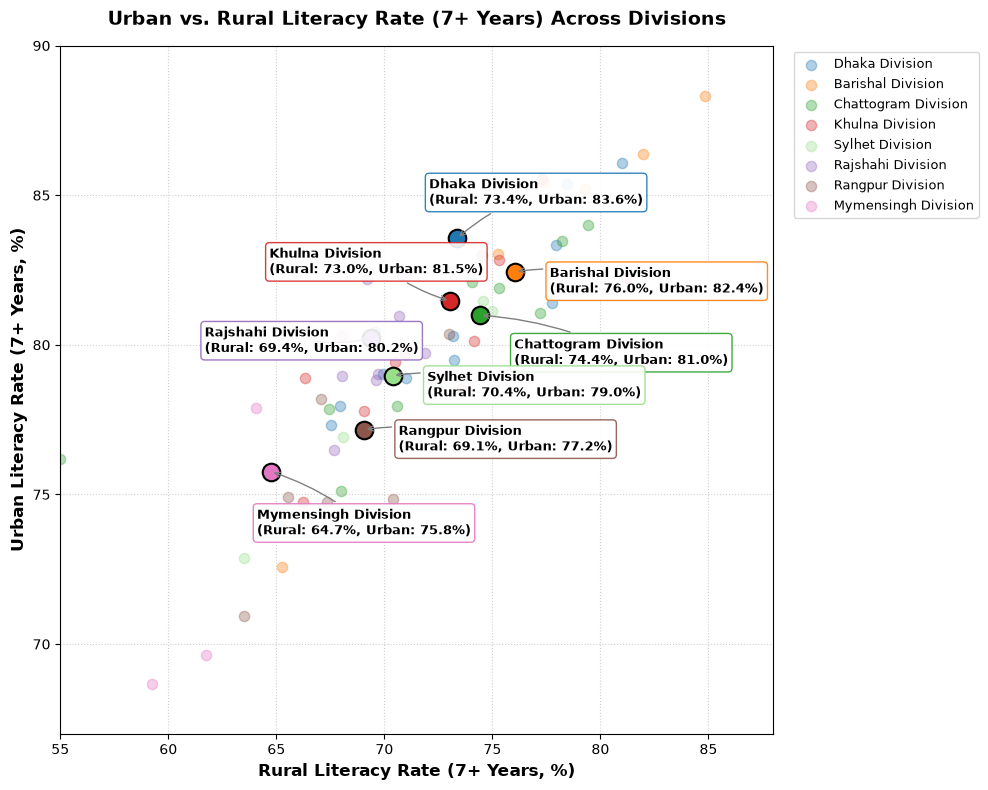

In [12]:
district_df = df.drop_duplicates(
    subset=["district"]
).copy()



district_df["Lit_Rural_7"] = pd.to_numeric(
    district_df["rural_literacy_rate_7year_overall"],
    errors="coerce"
)

district_df["Lit_Urban_7"] = pd.to_numeric(
    district_df["urban_literacy_rate_7year_overall"],
    errors="coerce"
)

district_df["Lit_Tot_7"] = pd.to_numeric(
    district_df["literacy_rate_7year_overall"],
    errors="coerce"
)


pop_rural_col = (
    "population_by_sex_dist_loca_population_rural_total_"
)

pop_urban_col = (
    "population_by_sex_dist_loca_population_urban_total_"
)

district_df["Pop_Rural"] = pd.to_numeric(
    district_df[pop_rural_col],
    errors="coerce"
)

district_df["Pop_Urban"] = pd.to_numeric(
    district_df[pop_urban_col],
    errors="coerce"
)


div_weighted = []

for div, group in district_df.groupby("division"):

    weighted_rural = (
        (group["Lit_Rural_7"] * group["Pop_Rural"]).sum()
        / group["Pop_Rural"].sum()
    )

    weighted_urban = (
        (group["Lit_Urban_7"] * group["Pop_Urban"]).sum()
        / group["Pop_Urban"].sum()
    )

    total_pop = (
        group["Pop_Rural"] + group["Pop_Urban"]
    )

    weighted_tot = (
        (group["Lit_Tot_7"] * total_pop).sum()
        / total_pop.sum()
    )

    div_weighted.append({
        "Division": f"{div} Division",
        "Lit_Rural_7": weighted_rural,
        "Lit_Urban_7": weighted_urban,
        "Lit_Tot_7": weighted_tot,
        "Gap": weighted_urban - weighted_rural,
    })

div_w_df = (
    pd.DataFrame(div_weighted)
    .sort_values(
        "Lit_Tot_7",
        ascending=False
    )
    .reset_index(drop=True)
)


fig, ax = plt.subplots(figsize=(10, 8))

divisions = [
    div.replace(" Division", "")
    for div in div_w_df["Division"]
]

colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#98df8a",
    "#9467bd",
    "#8c564b",
    "#e377c2",
]

div_color_map = dict(
    zip(divisions, colors)
)



offsets = {
    "Dhaka": (-20, 25),
    "Barishal": (25, -15),
    "Chattogram": (25, -35),
    "Khulna": (-130, 20),
    "Sylhet": (25, -15),
    "Rajshahi": (-120, -10),
    "Rangpur": (25, -15),
    "Mymensingh": (-10, -45),
}



for div in divisions:

    sub = district_df[
        district_df["division"] == div
    ]

    ax.scatter(
        sub["Lit_Rural_7"],
        sub["Lit_Urban_7"],
        alpha=0.35,
        s=55,
        color=div_color_map[div],
        label=f"{div} Division",
    )



for idx, row in div_w_df.iterrows():

    div_name = row["Division"].replace(
        " Division",
        ""
    )

    rx = row["Lit_Rural_7"]
    uy = row["Lit_Urban_7"]

   

    ax.scatter(
        rx,
        uy,
        s=160,
        color=div_color_map[div_name],
        edgecolors="black",
        linewidth=1.5,
        zorder=5,
    )


    ax.annotate(
        f"{row['Division']}\n"
        f"(Rural: {rx:.1f}%, Urban: {uy:.1f}%)",
        xy=(rx, uy),
        xytext=offsets.get(
            div_name,
            (10, 10)
        ),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="white",
            ec=div_color_map[div_name],
            alpha=0.9,
        ),
        arrowprops=dict(
            arrowstyle="->",
            connectionstyle="arc3,rad=0.1",
            color="gray",
            lw=1,
        ),
        zorder=6,
    )



ax.set_xlim(55, 88)
ax.set_ylim(67, 90)



ax.set_xlabel(
    "Rural Literacy Rate (7+ Years, %)",
    fontsize=12,
    fontweight="bold",
)

ax.set_ylabel(
    "Urban Literacy Rate (7+ Years, %)",
    fontsize=12,
    fontweight="bold",
)


ax.set_title(
    "Urban vs. Rural Literacy Rate (7+ Years) Across Divisions",
    fontsize=14,
    fontweight="bold",
    pad=15,
)



ax.grid(
    True,
    linestyle=":",
    alpha=0.6
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9,
    frameon=True,
)



plt.tight_layout()

plt.savefig(
    "urban_vs_rural_literacy_cleaned_mymensingh.png",
    dpi=300
)

plt.show()

### Dhaka Division has the highest urban literacy rate among all divisions, at 83.6%. However, Barishal Division records the highest rural literacy rate, with 76.0% of its rural population being literate. Furthermore, Mymensingh Division has the largest gap between urban and rural literacy rates, at 11.2 percentage points. In contrast, Barishal Division has the smallest gap, at only 6.4 percentage points.